In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
import itertools
import seaborn as sns
%matplotlib inline

# 1. Load the dataset data/data_banknote_authentication.txt and assign the following column names: "variance", "skewness", "curtosis", "entropy", "class"

In [2]:
df = pd.read_csv('../../data/data_banknote_authentication.txt', sep=',', names=["variance", "skewness", "curtosis", "entropy", "class"], header=None)
df

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [3]:
df.isnull().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

# 2. Plot in a bar chart the value distribution of the class column

<Axes: xlabel='class'>

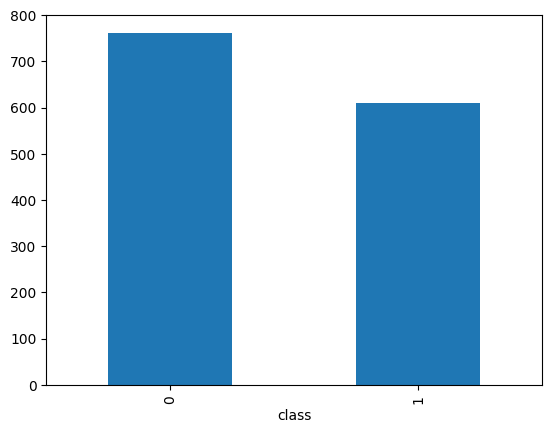

In [4]:
df['class'].value_counts().plot(kind='bar')

<Axes: xlabel='class', ylabel='count'>

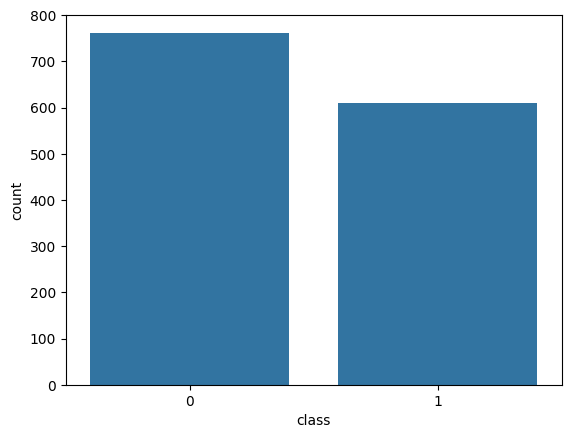

In [5]:
sns.countplot(x = df['class'])

# 3. Split the dataset in train and test

In [6]:
X = df.drop('class', axis=1)
y = df['class']

In [7]:
X

,variance,skewness,curtosis,entropy
0,3.62160,8.66610,-2.8073,-0.44699
1,4.54590,8.16740,-2.4586,-1.46210
2,3.86600,-2.63830,1.9242,0.10645
3,3.45660,9.52280,-4.0112,-3.59440
4,0.32924,-4.45520,4.5718,-0.98880
...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949
1368,-1.38870,-4.87730,6.4774,0.34179
1369,-3.75030,-13.45860,17.5932,-2.77710
1370,-3.56370,-8.38270,12.3930,-1.28230


In [8]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1367    1
1368    1
1369    1
1370    1
1371    1
Name: class, Length: 1372, dtype: int64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

# 4. Fit a LogisticRegression classifier

In [10]:
from sklearn import linear_model

model = linear_model.LogisticRegression()

In [11]:
model.fit(X_train, y_train)

LogisticRegression()

In [12]:
y_pred = model.predict(X_test)

# 5. Compute and plot the confusion matrix

In [13]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[192,   0],
       [  2, 149]])

<Axes: >

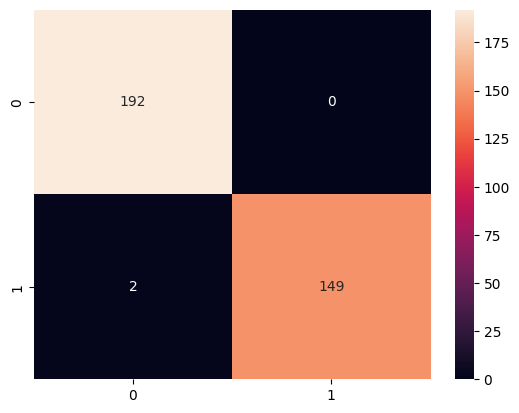

In [14]:
sns.heatmap(cm, annot=True, fmt='d')

# 6. Extract TP, TN, FP and FN

In [15]:
print('True Positive:', cm[0,0])
print('True Negative:', cm[1,1])
print('False Positive:', cm[1,0])
print('False Negative:', cm[0,1])

True Positive: 192
True Negative: 149
False Positive: 2
False Negative: 0


In [16]:
tp, fn, fp, tn = cm.ravel()

print('True Positive:', tp)
print('True Negative:', tn)
print('False Positive:', fp)
print('False Negative:', fn)

True Positive: 192
True Negative: 149
False Positive: 2
False Negative: 0


# 7. Compute accuracy, precision, recall and f1 score

In [17]:
from sklearn import metrics

In [18]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy {:0.2f}%".format(accuracy*100))

Accuracy 99.42%


In [19]:
precision = metrics.precision_score(y_test, y_pred)
print("Precision {:0.2f}%".format(precision*100))

Precision 100.00%


In [20]:
recall = metrics.recall_score(y_test, y_pred)
print("Recall {:0.2f}%".format(recall*100))

Recall 98.68%


In [21]:
f1 = metrics.f1_score(y_test, y_pred)
print("F1 Score {:0.2f}%".format(f1*100))

F1 Score 99.33%


# 8. Plot ROC and precision-recall curves

In [22]:
y_pred_proba = model.predict_proba(X_test)
y_pred_proba

array([[9.99999902e-01, 9.82067481e-08],
       [2.80826170e-02, 9.71917383e-01],
       [8.13186911e-02, 9.18681309e-01],
       [1.89158767e-05, 9.99981084e-01],
       [1.21279327e-02, 9.87872067e-01],
       [1.67644016e-03, 9.98323560e-01],
       [9.99977864e-01, 2.21363271e-05],
       [9.99999890e-01, 1.09844440e-07],
       [9.99999520e-01, 4.80243964e-07],
       [9.95929947e-01, 4.07005345e-03],
       [9.99999822e-01, 1.77533583e-07],
       [2.04509365e-04, 9.99795491e-01],
       [9.99999927e-01, 7.31880050e-08],
       [9.99977032e-01, 2.29678227e-05],
       [9.99988291e-01, 1.17087334e-05],
       [9.99999951e-01, 4.89071281e-08],
       [9.99999991e-01, 8.52248332e-09],
       [2.67279864e-04, 9.99732720e-01],
       [9.99999718e-01, 2.82397875e-07],
       [7.03008733e-04, 9.99296991e-01],
       [7.79213780e-05, 9.99922079e-01],
       [7.67225686e-01, 2.32774314e-01],
       [9.99987011e-01, 1.29887433e-05],
       [9.99999736e-01, 2.63634860e-07],
       [2.075309

In [23]:
# I want only the probabilities of the positive class, that is class 1, class "True"
y_pred_proba = y_pred_proba[:, 1]

## ROC curve

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

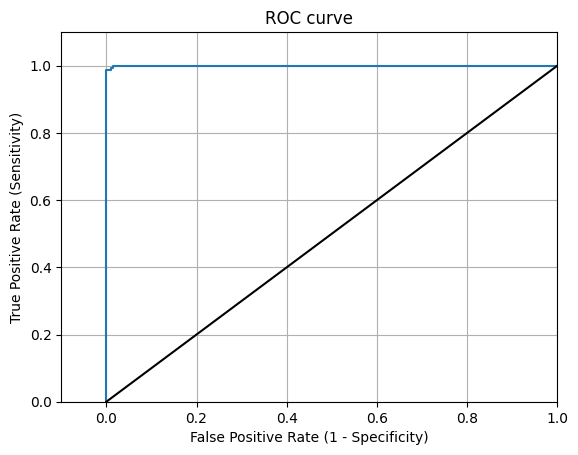

In [25]:
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k-',label='Random')
plt.xlim([-0.1, 1.0])
plt.ylim([0.0, 1.1])
plt.title('ROC curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

## Precision Recall curve

In [26]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

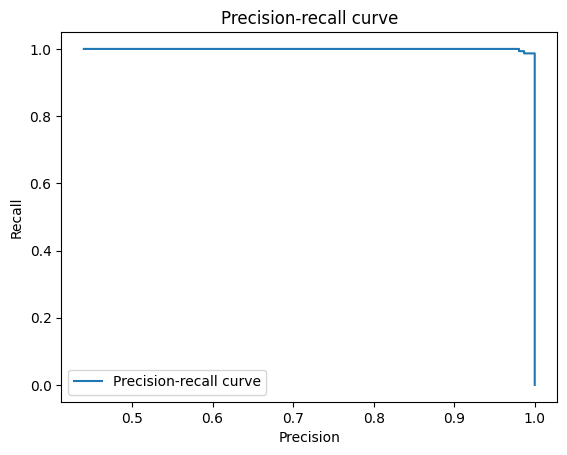

In [27]:
plt.plot(precision, recall, label='Precision-recall curve')
_ = plt.xlabel('Precision')
_ = plt.ylabel('Recall')
_ = plt.title('Precision-recall curve')
_ = plt.legend(loc="lower left")